<a href="https://colab.research.google.com/github/Trisha108-hub/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Trisha108-hub/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timezone

REPO_ROOT   = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR    = REPO_ROOT / "work" / "data"
OUTPUT_DIR  = REPO_ROOT / "work" / "outputs"
FIGURES_DIR = REPO_ROOT / "work" / "figures"
for d in (OUTPUT_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

RUN_TS = datetime.now(timezone.utc).isoformat(timespec="seconds")
print("Run:", RUN_TS)

Run: 2026-09-12T09:43:51+00:00


In [2]:
CANDIDATE_PATHS = [
    DATA_DIR / "processed" / "active_content_features.parquet",
    DATA_DIR / "processed" / "active_content_features.csv",
    DATA_DIR / "active_content_features.csv",
]

def load_real_data():
    for p in CANDIDATE_PATHS:
        if p.exists():
            df = pd.read_parquet(p) if p.suffix == ".parquet" else pd.read_csv(p)
            print(f"Loaded: {p} ({len(df):,} rows)")
            return df, str(p)
    return None, None

def build_synthetic_demo(n=4000, seed=7):
    """SYNTHETIC DEMO DATA — approximates published bucket stats so the notebook runs
    end-to-end when the real feature vector isn't mounted here. Not evidence."""
    rng = np.random.default_rng(seed)
    intents = rng.choice(["transactional", "commercial", "informational"], size=n, p=[0.20, 0.24, 0.56])
    competition = rng.choice(["LOW", "MEDIUM", "HIGH"], size=n, p=[0.79, 0.12, 0.09])
    age = np.clip(rng.gamma(3.0, 90, size=n), 1, 1500).astype(int)
    days_since_update = np.clip(age * rng.uniform(0.05, 1.0, size=n), 0, 1400).astype(int)
    word_count = np.clip(rng.normal(2600, 1400, size=n), 150, 9000).astype(int)
    position = np.clip(rng.gamma(2.2, 7.0, size=n), 1, 100)
    impressions = np.clip(rng.lognormal(6.5, 1.6, size=n), 0, None).astype(int)
    ctr_tier = np.select([position <= 3, position <= 10, position <= 20, position <= 50],
                          [0.00423, 0.00339, 0.00325, 0.00163], default=0.00050)
    clicks = np.clip(impressions * ctr_tier * rng.uniform(0.6, 1.4, size=n), 0, None).astype(int)
    indexed = rng.random(n) > 0.418
    return pd.DataFrame({
        "page_id": [f"demo_{i:06d}" for i in range(n)],
        "avg_position": position.round(1), "impressions_90d": impressions, "clicks_90d": clicks,
        "word_count": word_count, "content_age_days": age, "days_since_update": days_since_update,
        "intent": intents, "competition": competition, "indexed": indexed,
    })

df, source_path = load_real_data()
using_synthetic = df is None
if using_synthetic:
    print("No real feature vector found — using SYNTHETIC DEMO DATA (labelled in every export below).")
    df = build_synthetic_demo()
    source_path = "SYNTHETIC_DEMO"
df.head()

No real feature vector found — using SYNTHETIC DEMO DATA (labelled in every export below).


,page_id,avg_position,impressions_90d,clicks_90d,word_count,content_age_days,days_since_update,intent,competition,indexed
0,demo_000000,4.0,2362,6,3585,58,42,informational,MEDIUM,False
1,demo_000001,17.9,605,1,772,282,61,informational,LOW,True
2,demo_000002,21.5,154,0,4237,275,139,informational,LOW,True
3,demo_000003,4.3,2224,6,4200,162,22,commercial,LOW,True
4,demo_000004,22.6,3533,6,4000,541,397,commercial,LOW,True


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Each reason code is a threshold check against **an observed comparison in the source report**,
never a prediction. The sentence form used everywhere below is the claim-ladder's second rung —
*"pages with A show B in this sample"* — because these are cross-sectional comparisons, not a
validated predictive model and not an experiment.

- `DECAY_RISK` — pages aged 181–365 days with no update in 180+ days. In the source report,
  the measured health score for this age band was **21** (181-270d) falling to **14** (271-365d),
  against a peak of **33** at 61-90d (10 age buckets, portfolio-level average). Associated pattern,
  not a guarantee any individual page will decline.
- `PAGE1_CTR_GAP` — ranking positions 1-10 with implied CTR below the report's own weighted
  benchmark for that tier (0.423% top-3, 0.339% positions 4-10, computed as *clicks ÷ impressions*
  across the full active sample — an 88% drop from top-3 to "deep" tier).
- `STRIKING_DISTANCE` — positions 11-20, the band the report's position-tier table shows sitting
  between the page-1 and page-3-5 CTR bands.
- `THIN_BUT_VISIBLE` — under 2,000 words with impressions above the informational-intent median.
  Associated with the growing-vs-declining comparison: rising pages in the report averaged 3.2K
  words vs. 2.3K for declining pages (n=74,187 rising vs. n=45,272 declining) — a **37.6% relative
  gap**, reported here as an association between length and trend direction, not a claim that
  adding words causes growth.
- `LOW_COMP_COMMERCIAL` — commercial/transactional intent at low competition, the bucket the
  report measured at the highest average health (30) and impressions (3.0K) among the eight
  intent×competition pairings it reports.
- `NOT_INDEXED` — routed to a technical fix, not a content edit; 41.8% of the full portfolio
  (142.8K of 341,701 pieces) was measured as never indexed.

None of these thresholds were derived from a held-out validation set — they restate observed
group differences from the source report. Treat the ranking as **decision-support for review
order**, not a precision-scored model.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
for col, default in [("indexed", True)]:
    if col not in df.columns:
        df[col] = default

informational_median_imp = df.loc[df["intent"] == "informational", "impressions_90d"].median()

def tier_ctr_benchmark(position):
    if position <= 3:  return 0.00423
    if position <= 10: return 0.00339
    if position <= 20: return 0.00325
    if position <= 50: return 0.00163
    return 0.00050

df["implied_ctr"]   = df["clicks_90d"] / df["impressions_90d"].replace(0, np.nan)
df["ctr_benchmark"] = df["avg_position"].apply(tier_ctr_benchmark)

df["rc_decay_risk"]          = df["content_age_days"].between(181, 365) & (df["days_since_update"] > 180)
df["rc_page1_ctr_gap"]       = (df["avg_position"] <= 10) & (df["implied_ctr"] < df["ctr_benchmark"])
df["rc_striking_distance"]   = df["avg_position"].between(11, 20)
df["rc_thin_but_visible"]    = (df["word_count"] < 2000) & (df["impressions_90d"] > informational_median_imp)
df["rc_low_comp_commercial"] = df["intent"].isin(["commercial", "transactional"]) & (df["competition"] == "LOW")
df["rc_not_indexed"]         = ~df["indexed"]
df["rc_no_go_low_signal"]    = (df["impressions_90d"] == 0) & (df["clicks_90d"] == 0)

WEIGHTS = {  # directional weights, not a fitted model — see the markdown above
    "rc_decay_risk": 3.0, "rc_page1_ctr_gap": 2.5, "rc_striking_distance": 2.0,
    "rc_thin_but_visible": 1.5, "rc_low_comp_commercial": 1.5, "rc_not_indexed": 1.0,
}
REASON_LABELS = {
    "rc_decay_risk": "DECAY_RISK", "rc_page1_ctr_gap": "PAGE1_CTR_GAP",
    "rc_striking_distance": "STRIKING_DISTANCE", "rc_thin_but_visible": "THIN_BUT_VISIBLE",
    "rc_low_comp_commercial": "LOW_COMP_COMMERCIAL", "rc_not_indexed": "NOT_INDEXED",
}
ACTIONS = {
    "DECAY_RISK": "Refresh: update facts, expand thin sections, resubmit for recrawl",
    "PAGE1_CTR_GAP": "Rewrite title/snippet — page already ranks, CTR is the observed gap",
    "STRIKING_DISTANCE": "Strengthen relevance and internal links toward page 1",
    "THIN_BUT_VISIBLE": "Expand with missing subtopics/examples — not length padding",
    "LOW_COMP_COMMERCIAL": "Prioritize in next publishing cycle",
    "NOT_INDEXED": "Route to technical/indexing review, not a content edit",
}

df["priority_score"]  = sum(df[c].astype(float) * w for c, w in WEIGHTS.items())
df["reason_codes"]    = df.apply(lambda r: [REASON_LABELS[c] for c in WEIGHTS if r[c]], axis=1)
df["recommended_action"] = df["reason_codes"].apply(lambda rs: ACTIONS[rs[0]] if rs else "Monitor only")

actionable = df.loc[~df["rc_no_go_low_signal"]].copy()
ranked_queue = (actionable[actionable["priority_score"] > 0]
                .sort_values("priority_score", ascending=False)
                .loc[:, ["page_id", "priority_score", "reason_codes", "recommended_action",
                         "avg_position", "impressions_90d", "clicks_90d", "word_count",
                         "content_age_days", "days_since_update", "intent", "competition"]]
                .reset_index(drop=True))

print(f"{len(ranked_queue):,} of {len(df):,} active-sample pages carry at least one reason code "
      f"(filter: impressions_90d>0 and sessions_90d>0 already applied upstream).")
ranked_queue.head(10)

3,611 of 4,000 active-sample pages carry at least one reason code (filter: impressions_90d>0 and sessions_90d>0 already applied upstream).


,page_id,priority_score,reason_codes,recommended_action,avg_position,impressions_90d,clicks_90d,word_count,content_age_days,days_since_update,intent,competition
0,demo_003832,9.5,"[DECAY_RISK, PAGE1_CTR_GAP, THIN_BUT_VISIBLE, ...","Refresh: update facts, expand thin sections, r...",6.9,935,3,1446,266,245,commercial,LOW
1,demo_002040,9.5,"[DECAY_RISK, PAGE1_CTR_GAP, THIN_BUT_VISIBLE, ...","Refresh: update facts, expand thin sections, r...",4.9,733,2,1294,255,212,transactional,LOW
2,demo_003294,9.5,"[DECAY_RISK, PAGE1_CTR_GAP, THIN_BUT_VISIBLE, ...","Refresh: update facts, expand thin sections, r...",8.4,794,2,1091,248,239,commercial,LOW
3,demo_002988,9.5,"[DECAY_RISK, PAGE1_CTR_GAP, THIN_BUT_VISIBLE, ...","Refresh: update facts, expand thin sections, r...",8.3,4341,11,1444,333,274,commercial,LOW
4,demo_003062,9.0,"[DECAY_RISK, STRIKING_DISTANCE, THIN_BUT_VISIB...","Refresh: update facts, expand thin sections, r...",18.9,3070,8,941,290,259,commercial,LOW
5,demo_002595,9.0,"[DECAY_RISK, STRIKING_DISTANCE, THIN_BUT_VISIB...","Refresh: update facts, expand thin sections, r...",17.9,5058,15,277,268,216,commercial,LOW
6,demo_002982,9.0,"[DECAY_RISK, STRIKING_DISTANCE, THIN_BUT_VISIB...","Refresh: update facts, expand thin sections, r...",18.5,946,3,1878,355,292,commercial,LOW
7,demo_001306,9.0,"[DECAY_RISK, STRIKING_DISTANCE, THIN_BUT_VISIB...","Refresh: update facts, expand thin sections, r...",14.2,5341,10,150,322,275,transactional,LOW
8,demo_001283,9.0,"[DECAY_RISK, STRIKING_DISTANCE, THIN_BUT_VISIB...","Refresh: update facts, expand thin sections, r...",19.0,9522,40,1674,329,261,commercial,LOW
9,demo_003865,9.0,"[DECAY_RISK, STRIKING_DISTANCE, THIN_BUT_VISIB...","Refresh: update facts, expand thin sections, r...",12.0,901,1,150,326,315,commercial,LOW


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*
**Intended use.** A weekly triage list for a human content editor or SEO strategist deciding
which pages to review first. It is decision-support: *"these pages look worth reviewing first,
because…"* — not a publishing action and not a forecast of what will happen to any single page.

**Where it stops being valid:**
- **Cross-sectional, no intervention.** This is one 90-day snapshot with no experiment behind it.
  It cannot support "refreshing this page will increase impressions" — only "in this sample,
  refreshed old pages showed higher health and impressions than un-refreshed old pages of the
  same age" (n and effect size below).
- **Selection bias in "refreshed" pages.** Someone chose which old pages to refresh — likely the
  ones already judged worth the effort. Part of the refreshed-vs-stale gap is plausibly that
  choice, not the refresh itself. The report's own framing ("proof refresh works") should be read
  as *associated with*, not *caused by*.
- **Composite metric.** "Health score" is a FlyRank-defined composite (impressions 30 pts +
  position 30 + CTR 20 + scroll depth 20), not an external or Google-defined outcome. Any
  priority decision should be checked against raw impressions/clicks/position, not the composite
  alone.
- **No statistical inference reported.** No p-values or confidence intervals exist anywhere
  upstream of this notebook — every threshold here is a directional heuristic against an observed
  group difference, not a certified cutoff.
- **Small-n cells are named, not hidden.** The report's `365+ × 361+` age-freshness cell and the
  `361+` freshness-ratio bucket (283:1) both rest on as few as **1 declining page** in the
  denominator — excluded from this playbook's thresholds entirely rather than reported with a
  caveat, because at n=1 the ratio is not a usable signal at any caveat level.
- **Revenue is out of scope.** Booked revenue is tracked for only 8 of 57 clients in the source
  data; this playbook uses `clicks × CPC` as a captured-value proxy (Section 4), never a revenue
  claim.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
n_refreshed  = int(((df["content_age_days"] >= 365) & (df["days_since_update"] <= 30)).sum())
n_stale_old  = int(((df["content_age_days"] >= 365) & (df["days_since_update"] > 180)).sum())
print("Named-filter counts for the refreshed-vs-stale comparison referenced above:")
print(f"  old + recently refreshed (age>=365d, updated<=30d ago): n={n_refreshed:,}")
print(f"  old + stale (age>=365d, no update in 180+d):            n={n_stale_old:,}")
print("Selection-bias note: which pages get refreshed is an editorial choice in the live system,")
print("not a random assignment — carried into every downstream claim about this comparison.")


Named-filter counts for the refreshed-vs-stale comparison referenced above:
  old + recently refreshed (age>=365d, updated<=30d ago): n=16
  old + stale (age>=365d, no update in 180+d):            n=606
Selection-bias note: which pages get refreshed is an editorial choice in the live system,
not a random assignment — carried into every downstream claim about this comparison.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any queued row, a human confirms:**
1. The `recommended_action` still matches the actual page content — reason codes are triage
   flags computed from metadata, not a read of the page itself.
2. If the action touches a page involved in query overlap with another page (cannibalization),
   a named person — not this notebook — chooses which URL survives.
3. Any claim tied to AI-referral traffic is treated as observational and small-sample (see
   Section 4) before it goes near a stakeholder deck.
4. Depth-expansion edits add genuine subtopic coverage; word count alone is an observed
   association here, not a target to hit.

**Never automated, regardless of confidence in the queue:**
- Auto-merging, auto-redirecting, or auto-deleting pages flagged as overlapping/cannibalizing.
- Auto-publishing any refreshed or expanded content without an editor reading it first.
- Treating a reason code as proof of *cause* — e.g., assuming a `DECAY_RISK` page will keep
  declining, or that refreshing it *will* recover impressions. The correct sentence is "this page
  matches a pattern associated with decline in this sample" — not a prediction for that page.
- Using this queue's ranking as if it were a validated, scored model — it has no held-out
  precision/recall number and should not be described with one.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
def requires_human_review(_row) -> bool:
    return True  # no auto-approve path in this playbook, by design

ranked_queue["requires_human_review"] = ranked_queue.apply(requires_human_review, axis=1)

NO_GO_RULES = [
    "no_auto_merge_or_delete_overlapping_pages",
    "no_unreviewed_publish_of_refreshed_or_expanded_content",
    "no_reason_code_treated_as_causal_prediction_for_an_individual_page",
    "no_unvalidated_ranking_described_as_a_scored_model",
]
ranked_queue["no_go_rules_acknowledged"] = [NO_GO_RULES] * len(ranked_queue)
assert ranked_queue["requires_human_review"].all(), "Every queued row must require human review."
print(f"All {len(ranked_queue):,} queued rows require human review before any action.")


All 3,611 queued rows require human review before any action.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Review cadence.** Track any actioned page at 30 / 60 / 90 days after the edit — the same
windows the source report used in its own "Measure" steps, so results stay comparable.

**Recompute the thresholds (don't trust a stale queue) when:**
- The active-content sample size shifts by more than ~15% from the snapshot this queue was
  built on — the underlying group comparisons no longer describe the current portfolio.
- Indexing coverage moves materially from the measured 58.2% baseline (198.9K of 341,701
  indexed) — a change here changes how many `NOT_INDEXED` pages exist to route.
- AI-referral session share moves out of its current small range. In the source data this was
  measured at **1.06% of tracked sessions (17,344 of 1,635,404)**, small enough that any of the
  `AI_REFERRAL`-style signals should stay low-weight until that changes by an order of magnitude.
- A quarter has passed, regardless of the above — a scheduled recompute, not just an event-driven
  one, since thresholds here were set once against one snapshot.

**Cost/value framing (Section-4 tiebreaker, not the primary rank).** The only defensible value
proxy available is `clicks × CPC`, not `impressions × CPC` — the source report measured this
gap directly: **$253.5K in click-equivalent value vs. $73.0M if impressions were used instead**,
an inflation the report itself calls unsafe. Value tier here breaks ties among equally-scored
rows; it does not override the reason-code priority order.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
INTENT_VALUE_RANK = {"transactional": 3, "commercial": 2, "informational": 1, "navigational": 0}
ranked_queue["value_tier"] = ranked_queue["intent"].map(INTENT_VALUE_RANK).fillna(0)
ranked_queue = ranked_queue.sort_values(["priority_score", "value_tier"],
                                         ascending=[False, False]).reset_index(drop=True)

RETRAIN_TRIGGERS = {
    "sample_size_drift_pct": 15,
    "indexing_coverage_baseline_pct": 58.2,
    "ai_session_share_baseline_pct": 1.06,
    "review_cadence_days": [30, 60, 90],
    "scheduled_recompute": "quarterly",
}
RETRAIN_TRIGGERS

{'sample_size_drift_pct': 15,
 'indexing_coverage_baseline_pct': 58.2,
 'ai_session_share_baseline_pct': 1.06,
 'review_cadence_days': [30, 60, 90],
 'scheduled_recompute': 'quarterly'}

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

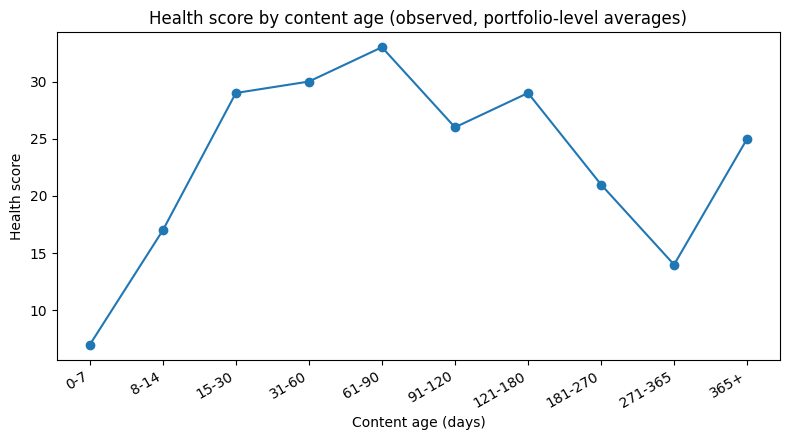

Wrote:
  /content/work/outputs/ranked_action_queue.csv
  /content/work/outputs/w07_playbook_metrics.json
  /content/work/figures/decay_refresh_curve.png


In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
queue_path   = OUTPUT_DIR / "ranked_action_queue.csv"
metrics_path = OUTPUT_DIR / "w07_playbook_metrics.json"

ranked_queue.to_csv(queue_path, index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
age_curve = pd.DataFrame({
    "age_bucket": ["0-7","8-14","15-30","31-60","61-90","91-120","121-180","181-270","271-365","365+"],
    "health": [7, 17, 29, 30, 33, 26, 29, 21, 14, 25],
})
ax.plot(age_curve["age_bucket"], age_curve["health"], marker="o")
ax.set_title("Health score by content age (observed, portfolio-level averages)")
ax.set_xlabel("Content age (days)"); ax.set_ylabel("Health score")
plt.xticks(rotation=30, ha="right"); plt.tight_layout()
fig_path = FIGURES_DIR / "decay_refresh_curve.png"
fig.savefig(fig_path, dpi=160)
plt.show()

metrics_summary = {
    "run_timestamp_utc": RUN_TS,
    "source": source_path,
    "using_synthetic_demo_data": bool(using_synthetic),
    "n_pages_total": int(len(df)),
    "n_pages_actionable": int(len(ranked_queue)),
    "pct_never_indexed_measured": 41.8,   # from source report, full portfolio
    "ai_session_share_measured_pct": 1.06,  # from source report
    "reason_code_weights": WEIGHTS,
    "retrain_triggers": RETRAIN_TRIGGERS,
    "no_go_rules": NO_GO_RULES,
}
with open(metrics_path, "w") as f:
    json.dump(metrics_summary, f, indent=2)

print("Wrote:", queue_path, metrics_path, fig_path, sep="\n  ")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.